# 24. 모델 학습 및 하이퍼파라미터 최적화 (Self-Contained Pipeline)

이 노트북은 README의 6장에 기술된 **UnderBagging Ensemble** 방식과 **단일 하이퍼파라미터 튜닝** 파이프라인을 독립적으로 실행할 수 있도록 통합 구성되었습니다.
이 노트북은 외부 스크립트(`src/train_core.py` 또는 `config/train_config.py`)에 의존하지 않고 자체적으로 구동됩니다.

### 실행 단계
1. **환경 및 설정**: 로컬 경로, 탐색 공간 및 하이퍼파라미터 범위 구성
2. **학습 엔진 구성**: SubsetTrainer, UnderbaggingEnsemble 및 각종 유틸리티 클래스 정의
3. **데이터 로드**: Full Train (10 Subsets), Full Validation, Sampled Validation 로드
4. **[Optuna Tuning] 하이퍼파라미터 탐색**: 넓은 탐색 공간, 가지치기(Pruning) 활성화, `n_estimators` 포함
5. **[Reranking] 최종 파라미터 선정**: Sampled 검증셋의 편향 리스크를 줄이기 위해 상위 후보들을 Full Validation으로 재평가
6. **최종 모델 저장**: 산출된 최적 파라미터 및 앙상블 모델을 저장

## 1. 라이브러리 임포트 및 독립 설정 구역

In [7]:
import sys, os, warnings, itertools, joblib, json, uuid, shutil
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")

# ── 한글 폰트 설정 ──────────────────────────────────────────
def _set_korean_font():
    candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
    for name in candidates:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

_set_korean_font()

# ── [독립 설정 클래스] ────────────────────────────────────────
class LocalConfig:
    # 1) 데이터 및 모델 저장 경로 설정
    DATA_ROOT = "../data2"      # 데이터 루트 폴더 (data 또는 data2)
    SUBSET_DIR = f"{DATA_ROOT}/06_hyperparameter_tuning/seed_42"
    VAL_TUNE_PATH = f"{DATA_ROOT}/06_hyperparameter_tuning/val_tune.parquet"
    VAL_TUNE_SAMPLED_PATH = f"{DATA_ROOT}/06_hyperparameter_tuning/seed_42/val_sampled.parquet"
    MODEL_SAVE_DIR = "../results/models/seed_42"

    # 2) 학습 타겟 변수 및 평가 임계값 목록
    TARGET_COL = "failure"
    SEED = 42
    EVAL_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5]

    # 3) LightGBM 기본 파라미터 (고정 항목들)
    LGBM_PARAMS = {
        "bagging_freq": 1,
        "verbosity": -1,
        "device": "cpu",
        "random_state": 42,
        "max_bin": 63,
    }

    # 4) Optuna 탐색 바운드 정의
    OPTUNA_BOUNDS = {
        "learning_rate": [0.005, 0.2],
        "max_depth": [3, 8],
        "num_leaves": [15, 255],
        "min_child_samples": [5, 100],
        "feature_fraction": [0.5, 1.0],
        "bagging_fraction": [0.5, 1.0],
        "n_estimators": [50, 300],
        "lambda_l1": [1e-8, 10.0],
        "lambda_l2": [1e-8, 10.0],
    }

    # 5) Optuna 튜닝 설정
    OPTUNA_TRIALS = 200
    OPTUNA_TIMEOUT = 3600000
    OPTUNA_DB_PATH = "../results/databases/optuna_study.db"
    OPTUNA_STUDY_NAME = "hdd_failure_prediction_seed_42"

print("✅ 독립 실행 환경 및 경로 구성 완료")

✅ 독립 실행 환경 및 경로 구성 완료


## 2. 언더배깅 앙상블 핵심 엔진 코드

In [8]:
# ── src/eval_core 임포트 ─────────────────────────────────────
ROOT = Path("../").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eval_core import (
    get_rolling_n_largest,
    prepare_disk_level_data,
    run_disk_level_grid_search,
    evaluate_detailed_disk_point,
)

print("✅ src/eval_core 임포트 완료")

@dataclass
class SubsetResult:
    """서브셋 하나의 학습 결과."""
    subset_id: int
    model: LGBMClassifier
    val_prauc: float
    n_train_pos: int
    n_train_neg: int

@dataclass
class EnsembleResult:
    """앙상블 최종 결과."""
    subset_results: list[SubsetResult]
    val_tune_prauc: float
    val_tune_probs: np.ndarray
    val_tune_y_true: np.ndarray
    models: list[LGBMClassifier] = field(default_factory=list)

    def __post_init__(self):
        self.models = [r.model for r in self.subset_results]

class SubsetTrainer:
    """단일 서브셋 모델 학습기."""
    def __init__(self, lgbm_params: dict, target_col: str = "failure"):
        self.lgbm_params = lgbm_params
        self.target_col = target_col
        self._meta = {"serial_number", "date", "days_to_failure", target_col}

    def _get_features(self, df: pd.DataFrame) -> list[str]:
        return [c for c in df.columns if c not in self._meta]

    def train(
        self,
        subset_id: int,
        df_subset: pd.DataFrame,
        feature_cols: Optional[list[str]] = None,
    ) -> SubsetResult:
        feats = feature_cols or self._get_features(df_subset)

        X_tr = df_subset[feats]
        y_tr = df_subset[self.target_col]

        model = LGBMClassifier(**self.lgbm_params)
        model.fit(X_tr, y_tr)

        return SubsetResult(
            subset_id=subset_id,
            model=model,
            val_prauc=0.0,
            n_train_pos=int(y_tr.sum()),
            n_train_neg=int((y_tr == 0).sum()),
        )

class UnderbaggingEnsemble:
    """비대칭 언더배깅 앙상블 (학습 후 일괄 검증 방식)."""
    def __init__(self, trainer: SubsetTrainer):
        self.trainer = trainer
        self._result: Optional[EnsembleResult] = None

    def fit(
        self,
        df_train_list: list[pd.DataFrame],
        df_val_tune: pd.DataFrame,
        feature_cols: Optional[list[str]] = None,
        target_col: str = "failure",
        trial: Optional[optuna.Trial] = None,
    ) -> EnsembleResult:
        subsets = df_train_list
        feats = feature_cols or [
            c for c in df_val_tune.columns
            if c not in {"serial_number", "date", "days_to_failure", target_col}
        ]

        # 특성 스키마 유효성 검증
        missing_val = set(feats) - set(df_val_tune.columns)
        if missing_val:
            raise ValueError(f"❌ [Error] 검증 데이터에 다음 특성이 누락되었습니다: {missing_val}")
            
        for i, sub in enumerate(subsets):
            missing_sub = set(feats) - set(sub.columns)
            if missing_sub:
                raise ValueError(f"❌ [Error] 훈련 서브셋 {i}에 다음 특성이 누락되었습니다: {missing_sub}")

        X_val = df_val_tune[feats].astype(np.float32)
        y_val = df_val_tune[target_col]

        subset_results: list[SubsetResult] = []
        probs_list = []
        is_optuna = trial is not None
        
        from sklearn.metrics import auc
        
        # 공통 df_eval_temp 준비
        df_eval_temp = pd.DataFrame({
            'serial_number': df_val_tune.loc[X_val.index, 'serial_number'],
            'date': df_val_tune.loc[X_val.index, 'date'],
            'failure': y_val
        })
        thresholds = np.linspace(0.001, 0.999, 100)

        for i, sub in enumerate(subsets):
            if is_optuna:
                msg = f"  🏋️  Trial {trial.number} - Subset {i+1}/{len(subsets)} 학습 중..."
            else:
                msg = f"  🏋️  Subset {i+1}/{len(subsets)} 학습 중..."
            print(f"\r{msg.ljust(60)}", end="", flush=True)
            res = self.trainer.train(
                subset_id=i,
                df_subset=sub,
                feature_cols=feature_cols,
            )
            subset_results.append(res)
            
            p = res.model.predict_proba(X_val)[:, 1]
            probs_list.append(p)
            
            # 단일 모델 디스크 단위 PR-AUC 평가
            disks_data, n_failed, n_normal = prepare_disk_level_data(df_eval_temp, p)
            df_grid = run_disk_level_grid_search(
                disks_data, thresholds, [1], n_failed, n_normal,
                log_dir=None, window_size=0, horizon=30
            )
            df_sorted = df_grid.sort_values(by="recall").copy()
            df_sorted["precision"] = df_sorted["tps"] / (df_sorted["tps"] + df_sorted["fps"] + 1e-8)
            df_sorted["precision"] = df_sorted["precision"].fillna(1.0)
            res.val_prauc = float(auc(df_sorted["recall"].values, df_sorted["precision"].values))
            
            if trial is not None:
                cur_probs = np.mean(probs_list, axis=0)
                disks_data_cur, n_failed_cur, n_normal_cur = prepare_disk_level_data(df_eval_temp, cur_probs)
                df_grid_cur = run_disk_level_grid_search(
                    disks_data_cur, thresholds, [1], n_failed_cur, n_normal_cur,
                     log_dir=None, window_size=0, horizon=30
                )
                df_sorted_cur = df_grid_cur.sort_values(by="recall").copy()
                df_sorted_cur["precision"] = df_sorted_cur["tps"] / (df_sorted_cur["tps"] + df_sorted_cur["fps"] + 1e-8)
                df_sorted_cur["precision"] = df_sorted_cur["precision"].fillna(1.0)
                cur_score = float(auc(df_sorted_cur["recall"].values, df_sorted_cur["precision"].values))
                
                trial.report(cur_score, step=i)
                if trial.should_prune():
                    print(f"\r  🚫  [Pruned] Trial {trial.number} pruned at step {i} (score: {cur_score:.5f})".ljust(60))
                    raise optuna.TrialPruned()

        if is_optuna:
            print("\r" + " " * 60 + "\r", end="", flush=True)
        else:
            print(f"\r✅  {len(subsets)}개 모델 학습 및 평가 완료.".ljust(60))

        probs = np.mean(probs_list, axis=0)
        disks_data_ens, n_failed_ens, n_normal_ens = prepare_disk_level_data(df_eval_temp, probs)
        df_grid_ens = run_disk_level_grid_search(
            disks_data_ens, thresholds, [1], n_failed_ens, n_normal_ens,
            log_dir=None, window_size=0, horizon=30
        )
        df_sorted_ens = df_grid_ens.sort_values(by="recall").copy()
        df_sorted_ens["precision"] = df_sorted_ens["tps"] / (df_sorted_ens["tps"] + df_sorted_ens["fps"] + 1e-8)
        df_sorted_ens["precision"] = df_sorted_ens["precision"].fillna(1.0)
        ensemble_prauc = float(auc(df_sorted_ens["recall"].values, df_sorted_ens["precision"].values))

        self._result = EnsembleResult(
            subset_results=subset_results,
            val_tune_prauc=ensemble_prauc,
            val_tune_probs=probs,
            val_tune_y_true=y_val.values if hasattr(y_val, "values") else y_val,
        )
        return self._result

✅ src/eval_core 임포트 완료


## 3. Optuna 목적함수 & Rerank 엔진 및 최적화 실행 함수

In [9]:
def make_optuna_objective(
    df_train: list[pd.DataFrame],
    df_val_tune: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "failure",
    device: str = "cpu",
    bounds: dict = None,
    save_model_dir: str = None,
):
    if bounds is None:
        raise ValueError("❌ 'bounds' (탐색 범위)가 지정되지 않았습니다.")

    def objective(trial):
        max_depth   = trial.suggest_int("max_depth", *bounds["max_depth"])
        max_leaves  = min(2 ** max_depth, bounds["num_leaves"][1])
        min_leaves  = min(bounds["num_leaves"][0], max_leaves)
        num_leaves  = trial.suggest_int("num_leaves", min_leaves, max_leaves)
        
        n_estimators = trial.suggest_int("n_estimators", *bounds["n_estimators"])
        scale_pos_weight = trial.suggest_float("scale_pos_weight", *bounds["scale_pos_weight"]) if "scale_pos_weight" in bounds else 1.0

        params = {
            "learning_rate":     trial.suggest_float("learning_rate", *bounds["learning_rate"], log=True),
            "max_depth":         max_depth,
            "num_leaves":        num_leaves,
            "min_child_samples": trial.suggest_int("min_child_samples", *bounds["min_child_samples"]),
            "feature_fraction":  trial.suggest_float("feature_fraction", *bounds["feature_fraction"]),
            "bagging_fraction":  trial.suggest_float("bagging_fraction", *bounds["bagging_fraction"]),
            "bagging_freq":      1,
            "lambda_l1":         trial.suggest_float("lambda_l1", *bounds["lambda_l1"], log=True),
            "lambda_l2":         trial.suggest_float("lambda_l2", *bounds["lambda_l2"], log=True),
            "n_estimators":      n_estimators,
            "scale_pos_weight":  scale_pos_weight,
            "verbosity":         -1,
            "device":            device,
            "random_state":      42,
            "max_bin":           63,
        }

        trainer = SubsetTrainer(lgbm_params=params, target_col=target_col)
        ens     = UnderbaggingEnsemble(trainer=trainer)
        result  = ens.fit(df_train, df_val_tune, feature_cols=feature_cols, target_col=target_col, trial=trial)
        
        if save_model_dir is not None:
            trial_id_str = f"trial_{trial.number}_{uuid.uuid4().hex[:8]}"
            trial_dir = Path(save_model_dir) / trial_id_str
            trial_dir.mkdir(parents=True, exist_ok=True)
            for i, model in enumerate(result.models):
                joblib.dump(model, trial_dir / f"model_{i}.pkl")
            trial.set_user_attr("model_dir", trial_id_str)
                
        return result.val_tune_prauc

    return objective

def run_training(
    cfg,
    feature_cols: Optional[list[str]] = None,
    *,
    run_optuna: bool = False,
    optuna_trials: Optional[int] = None,
    optuna_timeout: Optional[int] = None,
    optuna_rerank_delta: float = 0.005,
    optuna_rerank_cap: int = 5,
    optuna_rerank_ids: Optional[list[int]] = None,
    interactive_rerank: bool = False,
    cleanup_optuna_temp: bool = True,
) -> dict:
    import json
    import joblib
    from sklearn.metrics import auc
    
    # ── [이전 학습 결과 로드 및 요약 보기 결합 방어 로직] ───────────────────────
    # 1. 기존 완료된 Optuna Study가 있는지 확인 및 요약표 출력
    db_path = getattr(cfg, "OPTUNA_DB_PATH", "optuna_study.db")
    base_study_name = getattr(cfg, "OPTUNA_STUDY_NAME", "hdd_failure_prediction")
    storage_url = f"sqlite:///{db_path}"
    
    import optuna
    import joblib
    import pandas as pd
    
    study = None
    completed_trials = []
    if Path(db_path).exists():
        try:
            study = optuna.load_study(study_name=base_study_name, storage=storage_url)
            completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        except Exception:
            pass
            
    if completed_trials:
        df_trials = pd.DataFrame([
            {"Trial": t.number, "Sampled Disk Rolling PR-AUC": t.value}
            for t in completed_trials
        ]).sort_values("Sampled Disk Rolling PR-AUC", ascending=False)
        
        print("\n📊 [Optuna Trial 결과 요약 (기존 기록)]")
        print(df_trials.to_markdown(index=False))
        
    # 2. 이미 최종 학습 완료된 모델이 있는지 확인하고 로드 여부 질문
    save_dir = Path(cfg.MODEL_SAVE_DIR)
    expected_subsets = 5
    subset_dir = Path(getattr(cfg, "SUBSET_DIR", ""))
    if subset_dir.exists():
        expected_subsets = len(list(subset_dir.glob("subset_*.parquet"))) or 5
        
    best_params_path = save_dir / "best_params.json"
    feature_cols_path = save_dir / "feature_cols.json"
    models_exist = all((save_dir / f"subset_{i:02d}.pkl").is_file() for i in range(expected_subsets))
    
    if best_params_path.is_file() and feature_cols_path.is_file() and models_exist:
        print(f"\n🔄 [Load Existing] 기존 학습 완료된 모델 및 파라미터가 {save_dir}에 존재합니다.")
        try:
            user_load = input("👉 기존 학습된 모델을 로드하시겠습니까? (Y/n, Enter 입력 시 로드): ")
        except (EOFError, IOError, OSError):
            print("   -> 표준 입력을 사용할 수 없어 기존 모델을 자동으로 로드합니다.")
            user_load = "y"
        if user_load.strip().lower() not in ("n", "no"):
            print("   -> 기존 모델을 로드하여 결과를 반환합니다.")
            with open(best_params_path, "r", encoding="utf-8") as f:
                best_params = json.load(f)
            with open(feature_cols_path, "r", encoding="utf-8") as f:
                feats = json.load(f)
                
            models = []
            for i in range(expected_subsets):
                models.append(joblib.load(save_dir / f"subset_{i:02d}.pkl"))
                
            val_tune_path = getattr(cfg, "VAL_TUNE_PATH", None)
            if not val_tune_path or not Path(val_tune_path).exists():
                raise FileNotFoundError(f"❌ [Error] 원본 검증셋(VAL_TUNE_PATH)이 없습니다.")
            df_val_tune_full = pd.read_parquet(val_tune_path)
            
            result = evaluate_saved_models(models, df_val_tune_full, feats, getattr(cfg, "TARGET_COL", "failure"))
            return {"ensemble_result": result, "best_params": best_params, "feature_cols": feats}
        else: 
            print("   -> 재학습/리랭킹 모드로 진행합니다.")
    
    # 1. 파일 검증 및 로드
    subset_dir = Path(cfg.SUBSET_DIR)
    subset_files = sorted(list(subset_dir.glob("subset_*.parquet"))) if subset_dir.exists() else []
    if not subset_files:
        raise FileNotFoundError(f"❌ [Error] 사전 분할 데이터가 {subset_dir}에 없습니다.")

    # ⚠️ 안전장치: 고장 당일(D-DAY) 행 제외 (이미 제외되었을 수 있으나 이중 보장)
    def remove_dday_rows(df_to_clean, target_col):
        failed_serials = df_to_clean[df_to_clean[target_col] == 1]['serial_number'].unique()
        if len(failed_serials) > 0:
            df_failed = df_to_clean[df_to_clean['serial_number'].isin(failed_serials)]
            max_dates = df_failed.groupby('serial_number')['date'].max().reset_index()
            max_dates['is_dday'] = True
            cleaned = df_to_clean.merge(max_dates, on=['serial_number', 'date'], how='left')
            cleaned = cleaned[cleaned['is_dday'].isna()].drop(columns=['is_dday'])
            return cleaned
        return df_to_clean.copy()

    df_train = [pd.read_parquet(f) for f in subset_files]
    df_train = [remove_dday_rows(sub, cfg.TARGET_COL) for sub in df_train]
    
    val_tune_path = Path(cfg.VAL_TUNE_PATH)
    if not val_tune_path.exists():
        raise FileNotFoundError(f"❌ [Error] 원본 검증셋(VAL_TUNE_PATH)이 존재하지 않습니다.")
    df_val_tune_full = pd.read_parquet(val_tune_path)

    print(f"  [Debug] Train Subsets: {len(df_train)} files")
    print(f"  [Debug] Val Tune (Full) Rows: {len(df_val_tune_full):,}")
    
    sampled_path = Path(cfg.VAL_TUNE_SAMPLED_PATH)
    if run_optuna:
        if not sampled_path.exists():
            raise FileNotFoundError(f"❌ [Error] Optuna 모드에서는 샘플링된 검증셋({sampled_path})이 필수입니다.")
        df_val_optuna = pd.read_parquet(sampled_path)
        df_val_optuna = remove_dday_rows(df_val_optuna, cfg.TARGET_COL)
        print(f"  [Debug] Val Tune (Sampled for Optuna, D-day Excluded) loaded: {len(df_val_optuna):,} rows")
        is_val_sampled = True
    else:
        if sampled_path.exists():
            df_val_optuna = pd.read_parquet(sampled_path)
            df_val_optuna = remove_dday_rows(df_val_optuna, cfg.TARGET_COL)
            print(f"  [Debug] Val Tune (Sampled for Single Run, D-day Excluded) loaded: {len(df_val_optuna):,} rows")
            is_val_sampled = True
        else:
            df_val_optuna = df_val_tune_full
            print(f"  [Debug] Val Tune (Full for Single Run) Rows: {len(df_val_optuna):,}")
            is_val_sampled = False

    feats = feature_cols
    _device = cfg.LGBM_PARAMS.get("device", "cpu")

    # 2. Optuna 튜닝 시작
    best_params = cfg.LGBM_PARAMS.copy()
    if run_optuna:
        db_path = cfg.OPTUNA_DB_PATH
        base_study_name = cfg.OPTUNA_STUDY_NAME
        storage_url = f"sqlite:///{db_path}"

        trials = optuna_trials if optuna_trials is not None else cfg.OPTUNA_TRIALS
        print(f"\n  [Optuna Tuning] 하이퍼파라미터 탐색 시작 (설정 목표: {trials}회, 가지치기 활성화)")
        
        optuna_temp_dir = Path(cfg.MODEL_SAVE_DIR).parent / "optuna_temp"
        
        study = optuna.create_study(
            study_name=base_study_name,
            storage=storage_url,
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=cfg.SEED),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
            load_if_exists=True,
        )
        
        total_trials = len(study.trials)
        if total_trials < trials:
            obj = make_optuna_objective(
                df_train, df_val_optuna, feats, cfg.TARGET_COL, _device,
                bounds=cfg.OPTUNA_BOUNDS, save_model_dir=str(optuna_temp_dir)
            )
            
            # 매 Trial이 끝날 때마다 CSV에 즉시 저장하는 콜백 정의
            def save_csv_callback(study_obj, trial_obj):
                try:
                    csv_dir = Path(getattr(cfg, "METRICS_DIR", Path(cfg.OPTUNA_DB_PATH).parent))
                    csv_dir.mkdir(parents=True, exist_ok=True)
                    csv_path = csv_dir / "06d_optuna_trials.csv"
                    study_obj.trials_dataframe().to_csv(csv_path, index=False)
                except Exception as e:
                    print(f"\n  [Warning] CSV 실시간 저장 실패: {e}")
            
            study.optimize(
                obj, 
                n_trials=trials - total_trials, 
                timeout=optuna_timeout,
                callbacks=[save_csv_callback]
            )
        
        # 루프 종료 후 최종 저장 및 출력
        try:
            csv_dir = Path(getattr(cfg, "METRICS_DIR", Path(cfg.OPTUNA_DB_PATH).parent))
            csv_dir.mkdir(parents=True, exist_ok=True)
            csv_path = csv_dir / "06d_optuna_trials.csv"
            study.trials_dataframe().to_csv(csv_path, index=False)
            print(f"  [Saved] 모든 Trial 로그를 CSV로 최종 저장 완료: {csv_path}")
        except Exception as e:
            print(f"  [Warning] CSV 최종 저장 실패: {e}")
        
        valid_trials = [t for t in study.trials if t.number < trials and t.state == optuna.trial.TrialState.COMPLETE]
        if not valid_trials:
            raise ValueError(f"완료된 트라이얼이 없습니다. (목표 횟수: {trials})")
            
        best_trial = max(valid_trials, key=lambda t: t.value)
        print(f"  [Optuna Tuning] 완료. Best Disk Rolling PR-AUC (처음 {trials}회 기준): {best_trial.value:.5f}")

        # 3. Reranking (전체 검증셋 기준 재평가)
        if is_val_sampled and (optuna_rerank_delta > 0 or optuna_rerank_ids is not None or interactive_rerank):
            print(f"\n  [Rerank] Reranking 시작 (Full Validation)")
            completed_trials = valid_trials
            
            if completed_trials:
                df_trials = pd.DataFrame([
                    {"Trial": t.number, "Sampled Disk Rolling PR-AUC": t.value}
                    for t in completed_trials
                ]).sort_values("Sampled Disk Rolling PR-AUC", ascending=False)
                
                print("\n📊 [Optuna Trial 결과 요약]")
                print(df_trials.to_markdown(index=False))
                
                if interactive_rerank:
                    # 이전 선택 파일 로드 시도
                    selection_file = Path(cfg.MODEL_SAVE_DIR) / "optuna_rerank_selection.json"
                    prev_selected = None
                    if selection_file.is_file():
                        try:
                            import json
                            with open(selection_file, "r", encoding="utf-8") as sf:
                                prev_selected = json.load(sf).get("selected_ids")
                        except Exception:
                            pass

                    valid_ids = {t.number for t in completed_trials}
                    while True:
                        prompt = "\n📝 리랭크할 Trial 번호를 쉼표(,)로 구분하여 입력하세요 "
                        if prev_selected:
                            prompt += f"(이전 선택: {','.join(map(str, prev_selected))}, Enter 입력 시 유지, 'auto' 입력 시 자동 선택): "
                        else:
                            prompt += "(예: 0,2 / Enter 입력 시 자동 선택): "
                            
                        try:
                            user_input = input(prompt)
                        except (EOFError, IOError, OSError):
                            print("   -> 표준 입력을 사용할 수 없어 자동 선택/기존 선택을 적용합니다.")
                            user_input = ""
                        
                        if not user_input.strip():
                            if prev_selected:
                                optuna_rerank_ids = prev_selected
                                print(f"  -> 이전 선택 사용: {optuna_rerank_ids}")
                                break
                            else:
                                break
                                
                        if user_input.strip().lower() in ("auto", "a"):
                            optuna_rerank_ids = None
                            print("  -> 자동 Margin 기반 후보 선택 진행")
                            break
                        
                        try:
                            parsed_ids = [int(x.strip()) for x in user_input.split(",")]
                            invalid_ids = [x for x in parsed_ids if x not in valid_ids]
                            if invalid_ids:
                                print(f"  ⚠️ 에러: 트라이얼 번호 {invalid_ids}는 목록에 없습니다. 다시 입력해주세요.")
                                continue
                            optuna_rerank_ids = parsed_ids
                            break
                        except ValueError:
                            print("  ⚠️ 에러: 숫자와 쉼표(,) 또는 'auto'만 입력 가능합니다. 다시 입력해주세요.")
                
                # 선택 결과 저장
                if optuna_rerank_ids is not None:
                    try:
                        import json
                        Path(cfg.MODEL_SAVE_DIR).mkdir(parents=True, exist_ok=True)
                        selection_file = Path(cfg.MODEL_SAVE_DIR) / "optuna_rerank_selection.json"
                        with open(selection_file, "w", encoding="utf-8") as sf:
                            json.dump({"selected_ids": optuna_rerank_ids}, sf, indent=2)
                        print(f"  💾 리랭크 선택 번호가 저장되었습니다: {selection_file}")
                    except Exception as e:
                        print(f"  ⚠️ [Warning] 선택 번호 저장 실패: {e}")

                if optuna_rerank_ids is not None:
                    candidates = [t for t in completed_trials if t.number in optuna_rerank_ids]
                    print(f"  [Rerank] 지정된 트라이얼 리랭킹 진행: {len(candidates)}개 (IDs: {optuna_rerank_ids})")
                else:
                    best_val = max(t.value for t in completed_trials)
                    candidates = [t for t in completed_trials if t.value >= best_val - optuna_rerank_delta]
                    candidates = sorted(candidates, key=lambda t: t.value, reverse=True)[:optuna_rerank_cap]
                    print(f"  [Rerank] 자동 후보 선택: {len(candidates)}개 (best: {best_val:.5f}, delta: {optuna_rerank_delta})")
                
                best_rerank_score = -1.0
                best_rerank_params = None
                
                for trial_obj in candidates:
                    trial_number = trial_obj.number
                    cand_params = trial_obj.params
                    
                    merged_params = cfg.LGBM_PARAMS.copy()
                    merged_params.update(cand_params)
                    
                    model_dir_name = trial_obj.user_attrs.get("model_dir")
                    trial_dir = optuna_temp_dir / (model_dir_name if model_dir_name else f"trial_{trial_number}")
                    
                    if trial_dir.exists():
                        all_exist = all((trial_dir / f"model_{i}.pkl").exists() for i in range(len(df_train)))
                        if not all_exist:
                            print(f"    - Trial {trial_number} (Skipped): 모델 누락")
                            continue
                        try:
                            print(f"    - Trial {trial_number} 검증 중 (전체 데이터 추론)...", end="\r")
                            models = []
                            for i in range(len(df_train)):
                                model_path = trial_dir / f"model_{i}.pkl"
                                models.append(joblib.load(model_path))
                            
                            X_val = df_val_tune_full[feats]
                            y_val = df_val_tune_full[cfg.TARGET_COL]
                            probs = np.mean([m.predict_proba(X_val)[:, 1] for m in models], axis=0)
                            df_eval_temp_rerank = pd.DataFrame({
                                'serial_number': df_val_tune_full.loc[X_val.index, 'serial_number'],
                                'date': df_val_tune_full.loc[X_val.index, 'date'],
                                'failure': y_val
                            })
                            disks_data_rr, n_failed_rr, n_normal_rr = prepare_disk_level_data(df_eval_temp_rerank, probs)
                            thresholds_rr = np.linspace(0.001, 0.999, 1000)
                            df_grid_rr = run_disk_level_grid_search(
                                disks_data_rr, thresholds_rr, [1], n_failed_rr, n_normal_rr,
                                log_dir=None, window_size=0, horizon=30
                            )
                            df_sorted_rr = df_grid_rr.sort_values(by='recall').copy()
                            df_sorted_rr['precision'] = df_sorted_rr['tps'] / (df_sorted_rr['tps'] + df_sorted_rr['fps'] + 1e-8)
                            df_sorted_rr['precision'] = df_sorted_rr['precision'].fillna(1.0)
                            score = float(auc(df_sorted_rr['recall'].values, df_sorted_rr['precision'].values))
                            print(f"    - Trial {trial_number} (Reuse): Sampled Disk Rolling PR-AUC = {trial_obj.value:.5f} -> Full Disk Rolling PR-AUC = {score:.5f}")
                            
                            if score > best_rerank_score:
                                best_rerank_score = score
                                best_rerank_params = merged_params
                        except Exception as e:
                            print(f"    - Trial {trial_number} (Skipped): 로드 에러 ({type(e).__name__})")
                            continue
                    else:
                        print(f"    - Trial {trial_number} (Skipped): 저장 모델 없음")
                
                if best_rerank_params is not None:
                    best_params = best_rerank_params
                    print(f"  [Rerank] 최종 선택된 Full Disk Rolling PR-AUC: {best_rerank_score:.5f}")
            elif best_trial:
                best_params.update(best_trial.params)
        elif best_trial:
            best_params.update(best_trial.params)
            
    # 4. 최종 학습
    print("\n  [Final] 최적 파라미터로 최종 앙상블 학습 진행...")
    trainer = SubsetTrainer(lgbm_params=best_params, target_col=cfg.TARGET_COL)
    ens     = UnderbaggingEnsemble(trainer=trainer)
    result = ens.fit(df_train, df_val_tune_full, feature_cols=feats, target_col=cfg.TARGET_COL)

    # 임시 디렉토리 제거
    if run_optuna and cleanup_optuna_temp:
        optuna_temp_dir = Path(cfg.MODEL_SAVE_DIR).parent / "optuna_temp"
        if optuna_temp_dir.exists():
            shutil.rmtree(optuna_temp_dir, ignore_errors=True)
            print(f"\n  [Cleanup] 임시 폴더 {optuna_temp_dir} 삭제 완료.")

    return {"ensemble_result": result, "best_params": best_params, "feature_cols": feats}

## 4. 시각화 및 결과 리포트 함수

In [10]:
def print_ensemble_summary(result: EnsembleResult):
    print("\n" + "="*60)
    print("              UNDERBAGGING ENSEMBLE SUMMARY")
    print("="*60)
    print(f"  Final Ensemble Disk Rolling PR-AUC: {result.val_tune_prauc:.5f}")
    print("\n  서브셋별 VAL_TUNE Disk Rolling PR-AUC:")
    scores = [r.val_prauc for r in result.subset_results]
    for i, s in enumerate(scores):
        print(f"    Subset {i+1:02d}: {s:.5f}")
    print(f"\n  평균 (단순): {np.mean(scores):.5f}  ±  {np.std(scores):.5f}")
    print("="*60)

def plot_subset_prauc(result: EnsembleResult):
    scores = [r.val_prauc for r in result.subset_results]
    plt.figure(figsize=(10, 4))
    plt.bar(range(1, len(scores)+1), scores, color='skyblue', edgecolor='navy')
    plt.axhline(result.val_tune_prauc, color='red', linestyle='--', label=f'Ensemble ({result.val_tune_prauc:.4f})')
    plt.title('Disk Rolling PR-AUC by Subset Model', fontweight='bold')
    plt.xlabel('Subset ID'); plt.ylabel('Disk Rolling PR-AUC')
    plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.show()

def plot_confusion_matrix(result: EnsembleResult, cfg):
    """임계값별 디스크 단위 혼동행렬 시각화 (개수 및 비율 포함)."""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import itertools
    from pathlib import Path
    
    # 1. 원본 검증 데이터 로드 (시리얼 및 날짜 매칭용)
    val_path = getattr(cfg, "VAL_TUNE_PATH", None)
    if not val_path or not Path(val_path).exists():
        print("⚠️ [Warning] VAL_TUNE_PATH가 존재하지 않아 디스크 단위 혼동행렬을 그릴 수 없습니다.")
        return
        
    df_val = pd.read_parquet(val_path)
    df_eval = pd.DataFrame({
        'serial_number': df_val['serial_number'],
        'date': df_val['date'],
        'failure': df_val[getattr(cfg, "TARGET_COL", "failure")]
    })
    
    probs = result.val_tune_probs
    disks_data, n_failed, n_normal = prepare_disk_level_data(df_eval, probs)
    thresholds = getattr(cfg, "EVAL_THRESHOLDS", [0.1, 0.2, 0.3, 0.4, 0.5])
    
    fig, axes = plt.subplots(1, len(thresholds), figsize=(4.5 * len(thresholds), 4.5))
    if len(thresholds) == 1: axes = [axes]
    
    for ax, thr in zip(axes, thresholds):
        tps, fns, fps, tns = 0, 0, 0, 0
        for disk in disks_data:
            is_failed = disk['is_failed']
            y_pred = (disk['probs'] >= thr).astype(int)
            
            # 최소 알림 발생 횟수 n = 1 (경보 발생 여부)
            is_alarmed = int(y_pred.sum() >= 1)
            
            if is_failed == 1:
                if is_alarmed == 1:
                    trigger_idx = np.where(y_pred == 1)[0][0]
                    trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
                    last_date = pd.to_datetime(disk['dates'][-1])
                    lead_time = (last_date - trigger_date).days
                    
                    # 30일 리드타임 이내인 경우만 TP
                    if lead_time <= 30:
                        tps += 1
                    else:
                        fns += 1
                else:
                    fns += 1
            else:
                if is_alarmed == 1:
                    fps += 1
                else:
                    tns += 1
                    
        cm = np.array([[tns, fps], [fns, tps]])
        ax.imshow(cm, interpolation='nearest', cmap='Oranges')
        
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(2), range(2)):
            count = cm[i, j]
            pct = count / cm.sum() * 100
            ax.text(j, i, f"{count:,}\n({pct:.2f}%)",
                    ha="center", color="white" if count > thresh else "black",
                    fontsize=11, fontweight='bold')
                    
        ax.set_title(f'Threshold = {thr}', fontsize=12, fontweight='bold', pad=15)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['Normal', 'Failure'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['Normal', 'Failure'])
        ax.set_xlabel('Predicted Label', fontweight='bold')
        ax.set_ylabel('True Label', fontweight='bold')
        
    plt.suptitle('Disk-Level Confusion Matrix (30d Lead Time, n=1)', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


## 5. 데이터 준비 및 특성 선택

In [11]:
# 학습용 데이터 서브셋 중 임의의 서브셋 하나를 로드해 피처 수 파악
subset_dir = Path(LocalConfig.SUBSET_DIR)
subset_files = sorted(list(subset_dir.glob("subset_*.parquet")))
if not subset_files:
    raise FileNotFoundError(f"❌ [Error] {subset_dir}에 학습 서브셋 파일이 없습니다.")

df_sample_sub = pd.read_parquet(subset_files[0])
_meta = {'serial_number', 'date', 'failure', 'days_to_failure'}
FEATURE_COLS = [c for c in df_sample_sub.columns if c not in _meta]

df_val_tune = pd.read_parquet(LocalConfig.VAL_TUNE_PATH)
pos_val = df_val_tune[LocalConfig.TARGET_COL].mean()

print(f"학습용 특성 개수 : {len(FEATURE_COLS)} 개")
print(f"검증셋 로우 수    : {len(df_val_tune):,} rows (pos_rate={pos_val:.5f})")


학습용 특성 개수 : 17 개
검증셋 로우 수    : 7,758,369 rows (pos_rate=0.00224)


## 6. Optuna 하이퍼파라미터 최적화 & 최종 앙상블 학습

In [12]:
result_dict = run_training(
    cfg=LocalConfig,
    feature_cols=FEATURE_COLS,
    run_optuna=True,
    optuna_trials=LocalConfig.OPTUNA_TRIALS,
    interactive_rerank=True,
    cleanup_optuna_temp=False,
    optuna_timeout=LocalConfig.OPTUNA_TIMEOUT,
)

ens_result = result_dict['ensemble_result']
best_params = result_dict['best_params']


📊 [Optuna Trial 결과 요약 (기존 기록)]
|   Trial |   Sampled Disk Rolling PR-AUC |
|--------:|------------------------------:|
|     174 |                      0.299737 |
|      74 |                      0.297507 |
|     158 |                      0.296458 |
|     137 |                      0.296114 |
|     125 |                      0.295932 |
|     144 |                      0.295154 |
|     134 |                      0.294897 |
|      25 |                      0.29479  |
|      82 |                      0.294514 |
|     145 |                      0.294293 |
|     168 |                      0.294099 |
|     113 |                      0.293873 |
|      88 |                      0.293756 |
|     162 |                      0.293557 |
|      70 |                      0.293527 |
|      91 |                      0.29305  |
|     193 |                      0.292836 |
|     123 |                      0.292817 |
|      83 |                      0.292731 |
|      71 |                      0.291573 |


[I 2026-05-31 19:23:41,865] Using an existing study with name 'hdd_failure_prediction_seed_42' instead of creating a new one.


  [Debug] Val Tune (Sampled for Optuna, D-day Excluded) loaded: 1,297,360 rows

  [Optuna Tuning] 하이퍼파라미터 탐색 시작 (설정 목표: 200회, 가지치기 활성화)
  [Saved] 모든 Trial 로그를 CSV로 최종 저장 완료: ..\results\databases\06d_optuna_trials.csv
  [Optuna Tuning] 완료. Best Disk Rolling PR-AUC (처음 200회 기준): 0.29974

  [Rerank] Reranking 시작 (Full Validation)

📊 [Optuna Trial 결과 요약]
|   Trial |   Sampled Disk Rolling PR-AUC |
|--------:|------------------------------:|
|     174 |                      0.299737 |
|      74 |                      0.297507 |
|     158 |                      0.296458 |
|     137 |                      0.296114 |
|     125 |                      0.295932 |
|     144 |                      0.295154 |
|     134 |                      0.294897 |
|      25 |                      0.29479  |
|      82 |                      0.294514 |
|     145 |                      0.294293 |
|     168 |                      0.294099 |
|     113 |                      0.293873 |
|      88 |                    

## 7. 최종 평가 리포트


🏆 최종 선택된 최적 하이퍼파라미터
  - bagging_freq: 1
  - verbosity: -1
  - device: cpu
  - random_state: 42
  - max_bin: 63
  - max_depth: 3
  - num_leaves: 8
  - n_estimators: 201
  - learning_rate: 0.09015397967744407
  - min_child_samples: 65
  - feature_fraction: 0.9363022194231662
  - bagging_fraction: 0.6706260307899081
  - lambda_l1: 8.435482005006008e-08
  - lambda_l2: 0.000535963801272402

              UNDERBAGGING ENSEMBLE SUMMARY
  Final Ensemble Disk Rolling PR-AUC: 0.31496

  서브셋별 VAL_TUNE Disk Rolling PR-AUC:
    Subset 01: 0.29111
    Subset 02: 0.28524
    Subset 03: 0.31693
    Subset 04: 0.31944
    Subset 05: 0.31107

  평균 (단순): 0.30476  ±  0.01394


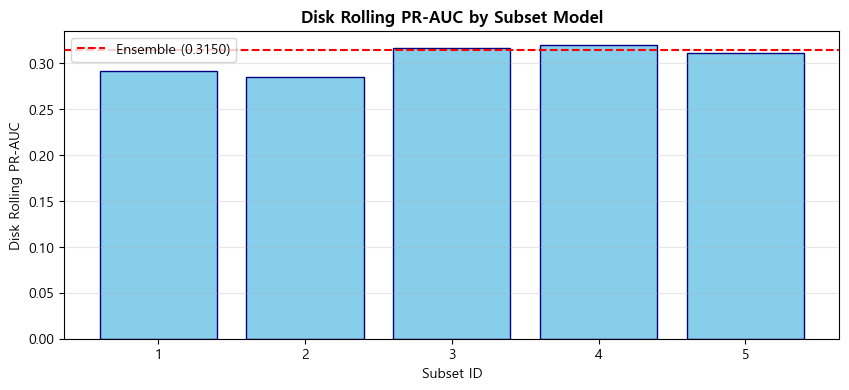

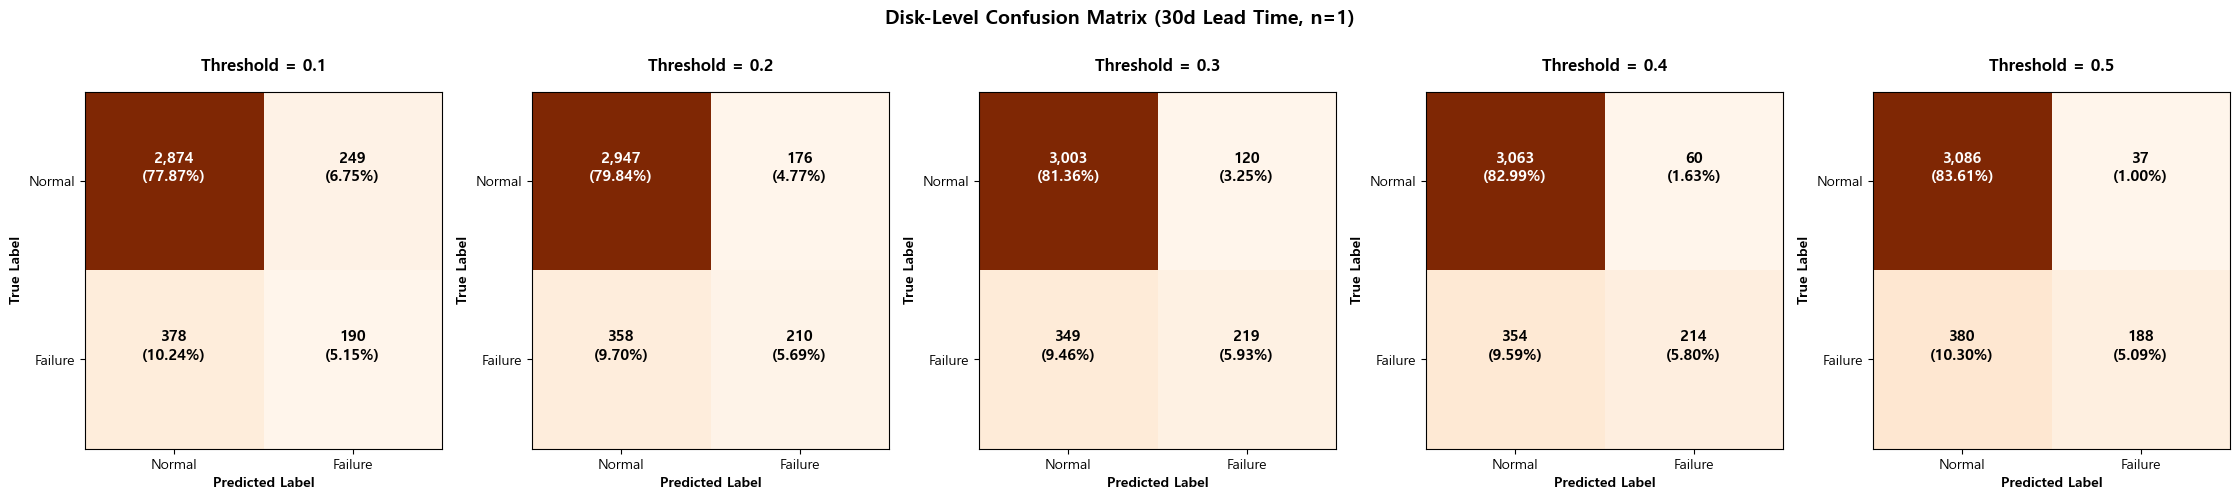

In [13]:
print('\n=========================================')
print('🏆 최종 선택된 최적 하이퍼파라미터')
print('=========================================')
for k, v in best_params.items():
    print(f'  - {k}: {v}')

print_ensemble_summary(ens_result)
plot_subset_prauc(ens_result)
plot_confusion_matrix(ens_result, LocalConfig)

## 8. 모델 및 학습 설정 저장

In [14]:
import os
import sys
import json
import joblib
import shutil
import optuna
from pathlib import Path

SAVE_DIR = Path(LocalConfig.MODEL_SAVE_DIR)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Optuna DB에서 완료된 트라이얼 정보 조회
db_path = getattr(LocalConfig, "OPTUNA_DB_PATH", "notebooks2/optuna_study.db")
study_name = getattr(LocalConfig, "OPTUNA_STUDY_NAME", "hdd_failure_prediction_seed_42")

try:
    study = optuna.load_study(study_name=study_name, storage=f"sqlite:///{db_path}")
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    best_trial = study.best_trial
    print(f"📊 로드된 Optuna Study: {study_name}")
    print(f"  - 총 완료된 트라이얼 수: {len(completed_trials)}개")
    print(f"  - Optuna 추천 Best Trial: #{best_trial.number} (Disk Rolling PR-AUC: {best_trial.value:.5f})")
except Exception as e:
    study = None
    completed_trials = []
    print(f"⚠️ Optuna Study 로드 실패 (단일 학습 실행 상태일 수 있음): {e}")

# 2. 사용자로부터 내보낼 Trial ID 입력 받기
selected_trial_id = None
if study is not None and completed_trials:
    try:
        user_input = input(f"\n📝 최종 모델로 내보낼 Optuna Trial 번호를 입력하세요 (Enter 입력 시 157번 자동 지정): ")
        user_input = user_input.strip()
        if not user_input:
            selected_trial_id = 157
        else:
            selected_trial_id = int(user_input)
    except (EOFError, IOError, OSError, ValueError):
        print("👉 비대화형 환경이거나 잘못된 입력으로 157번 Trial을 최종 모델로 자동 지정합니다.")
        selected_trial_id = 157
else:
    print("\n👉 Optuna Study가 없어 현재 단일 실행 결과를 최종 모델로 내보냅니다.")

# 3. 모델 파일 및 파라미터 내보내기 수행
if selected_trial_id is not None and study is not None:
    # 지정된 Trial 찾기
    matched_trials = [t for t in completed_trials if t.number == selected_trial_id]
    if not matched_trials:
        raise ValueError(f"❌ [Error] 지정한 Trial #{selected_trial_id}번을 완료된 트라이얼 목록에서 찾을 수 없습니다.")
    
    trial = matched_trials[0]
    print(f"\n🚀 Trial #{trial.number} 모델 내보내기 진행 (Sampled Disk Rolling PR-AUC: {trial.value:.5f})...")
    
    # 하이퍼파라미터 구성 및 저장
    export_params = LocalConfig.LGBM_PARAMS.copy()
    export_params.update(trial.params)
    
    # 모델 디렉토리 확인 및 복사
    model_dir_name = trial.user_attrs.get("model_dir")
    optuna_temp_dir = Path(LocalConfig.MODEL_SAVE_DIR).parent / "optuna_temp"
    trial_dir = optuna_temp_dir / (model_dir_name if model_dir_name else f"trial_{trial.number}")
    
    if not trial_dir.exists():
        raise FileNotFoundError(f"❌ [Error] Trial #{trial.number}의 모델들이 저장된 임시 폴더 {trial_dir}를 찾을 수 없습니다.")
        
    # 모델 복사 및 이름 변경 (model_i.pkl -> subset_0i.pkl)
    model_files = sorted(list(trial_dir.glob("model_*.pkl")))
    if not model_files:
        raise FileNotFoundError(f"❌ [Error] {trial_dir} 내에 .pkl 모델 파일이 존재하지 않습니다.")
        
    for idx, model_file in enumerate(model_files):
        dest_path = SAVE_DIR / f"subset_{idx:02d}.pkl"
        shutil.copy2(model_file, dest_path)
        print(f"  [Saved] 모델 복사 완료: {dest_path}")
        
    # best_params json 저장
    param_path = SAVE_DIR / 'best_params.json'
    with open(param_path, 'w', encoding='utf-8') as f:
        json.dump(export_params, f, ensure_ascii=False, indent=2)
    print(f'  [Saved] 최적 파라미터 저장 완료: {param_path}')

else:
    # 단일 실행 시 결과 저장 (기존 백업용 로직)
    print("\n🚀 현재 단일 실행 앙상블 모델 내보내기 진행...")
    for i, model in enumerate(ens_result.models):
        path = SAVE_DIR / f'subset_{i:02d}.pkl'
        joblib.dump(model, path)
        print(f'  [Saved] 모델 저장: {path}')
        
    param_path = SAVE_DIR / 'best_params.json'
    with open(param_path, 'w', encoding='utf-8') as f:
        json.dump(best_params, f, ensure_ascii=False, indent=2)
    print(f'  [Saved] 최적 파라미터 저장 완료: {param_path}')

# 4. 공통 학습 특성 정의 json 저장
feat_path = SAVE_DIR / 'feature_cols.json'
feature_list = result_dict['feature_cols'] if 'result_dict' in globals() else FEATURE_COLS
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(feature_list, f, ensure_ascii=False, indent=2)
print(f'  [Saved] 피처 목록 저장 완료: {feat_path}')

print("\n🎉 최종 모델 내보내기 완료!")

📊 로드된 Optuna Study: hdd_failure_prediction_seed_42
  - 총 완료된 트라이얼 수: 129개
  - Optuna 추천 Best Trial: #174 (Disk Rolling PR-AUC: 0.29974)

🚀 Trial #158 모델 내보내기 진행 (Sampled Disk Rolling PR-AUC: 0.29646)...
  [Saved] 모델 복사 완료: ..\results\models\seed_42\subset_00.pkl
  [Saved] 모델 복사 완료: ..\results\models\seed_42\subset_01.pkl
  [Saved] 모델 복사 완료: ..\results\models\seed_42\subset_02.pkl
  [Saved] 모델 복사 완료: ..\results\models\seed_42\subset_03.pkl
  [Saved] 모델 복사 완료: ..\results\models\seed_42\subset_04.pkl
  [Saved] 최적 파라미터 저장 완료: ..\results\models\seed_42\best_params.json
  [Saved] 피처 목록 저장 완료: ..\results\models\seed_42\feature_cols.json

🎉 최종 모델 내보내기 완료!


## 9. 학습 결과물 및 파라미터 파일 무결성 검증 테스트 (Verification Tests)

최종적으로 저장된 서브셋 모델 파일들(`subset_00.pkl` 등), 피처 컬럼 정의 파일(`feature_cols.json`), 그리고 최적화된 하이퍼파라미터 설정 파일(`best_params.json`)의 저장 여부 및 정상 로딩 상태를 검증합니다.


In [15]:
SAVE_DIR = Path(LocalConfig.MODEL_SAVE_DIR)

print("🔍 [6-D단계 무결성 검증] 시작...")

try:
    # 1. 서브셋 모델 pkl 파일 물리 저장 확인 및 로딩 테스트
    subset_dir = Path(LocalConfig.SUBSET_DIR)
    expected_subsets = len(list(subset_dir.glob("subset_*.parquet")))
    print(f"Test 1: {expected_subsets}개 서브셋 모델 저장 및 로딩 검증")
    loaded_models = []
    for i in range(expected_subsets):
        path = SAVE_DIR / f'subset_{i:02d}.pkl'
        assert path.is_file(), f"오류: 모델 파일 {path.name}이 존재하지 않습니다."
        model = joblib.load(path)
        assert hasattr(model, 'predict_proba'), f"오류: {path.name} 파일이 올바른 모델 객체가 아닙니다."
        loaded_models.append(model)
    print(f"  -> [PASS] {expected_subsets}개 서브셋 모델 pkl 파일 무결성 확인 완료.")

    # 2. 피처 컬럼 json 파일 검증
    print("Test 2: feature_cols.json 저장 및 로딩 검증")
    feat_path = SAVE_DIR / 'feature_cols.json'
    assert feat_path.is_file(), "오류: feature_cols.json 파일이 존재하지 않습니다."
    with open(feat_path, 'r', encoding='utf-8') as f:
        feats = json.load(f)
    assert isinstance(feats, list) and len(feats) > 0, "오류: feature_cols.json 형식이 올바르지 않습니다."
    print(f"  -> [PASS] feature_cols.json 무결성 확인 완료. (총 {len(feats)}개 피처)")

    # 3. 최적 파라미터 json 파일 검증
    print("Test 3: best_params.json 저장 및 로딩 검증")
    param_path = SAVE_DIR / 'best_params.json'
    assert param_path.is_file(), "오류: best_params.json 파일이 존재하지 않습니다."
    with open(param_path, 'r', encoding='utf-8') as f:
        params = json.load(f)
    assert isinstance(params, dict) and 'n_estimators' in params, "오류: best_params.json 형식이 올바르지 않거나 필수 키가 누락되었습니다"
    print("  -> [PASS] best_params.json 무결성 확인 완료.")

    # ── 강화 4: 모델 feature 수와 feature_cols.json 일치 검증 ──
    print("Test 4: 모델 feature 수와 feature_cols.json 일치 검증")
    for i, model in enumerate(loaded_models):
        if hasattr(model, 'n_features_in_'):
            assert model.n_features_in_ == len(feats), (
                f"오류: 모델 {i}의 feature 수({model.n_features_in_})가 "
                f"feature_cols.json({len(feats)})과 불일치!"
            )
    print("  -> [PASS] 모든 모델의 feature 수 일치.")

    # ── 강화 5: best_params.json 필수 키 전체 검증 ──
    print("Test 5: best_params.json 필수 키 전체 존재 검증")
    required_keys = ['n_estimators', 'learning_rate', 'max_depth', 'num_leaves']
    for key in required_keys:
        assert key in params, f"오류: best_params.json에 필수 키 '{key}'가 누락되었습니다"
    assert isinstance(params['n_estimators'], int) and params['n_estimators'] > 0, "오류: n_estimators가 양의 정수가 아닙니다"
    assert 0 < params['learning_rate'] <= 1.0, f"오류: learning_rate 범위 이상: {params['learning_rate']}"
    print("  -> [PASS] best_params.json 필수 키 및 값 범위 정상.")

    # ── 강화 6: 모델 predict_proba 출력 범위 검증 ──
    print("Test 6: 모델 predict_proba 출력 범위(0~1) 검증")
    import numpy as np
    dummy_input = np.zeros((1, len(feats)))
    for i, model in enumerate(loaded_models):
        proba = model.predict_proba(dummy_input)
        assert proba.shape[1] == 2, f"오류: 모델 {i} predict_proba 출력이 2-class가 아닙니다"
        assert 0.0 <= proba[0, 1] <= 1.0, f"오류: 모델 {i} 확률 범위 이상: {proba[0, 1]}"
    print("  -> [PASS] 모든 모델 predict_proba 출력 범위 정상.")

    # ── 강화 7: 앙상블 모델 간 feature 일관성 검증 ──
    print("Test 7: 앙상블 모델 간 feature name 일관성 검증")
    for i, model in enumerate(loaded_models):
        if hasattr(model, 'feature_name_'):
            model_feats = model.feature_name_
            assert list(model_feats) == feats, (
                f"오류: 모델 {i}의 feature name이 feature_cols.json과 불일치!"
            )
    print("  -> [PASS] 모든 앙상블 모델 feature name 일관성 확인.")

    print("\n✅ [6-D단계 통합성 검증 완료] 모든 학습 결과물이 정상적으로 저장되고 로드 가능합니다! (7/7 PASS)")
finally:
    pass


🔍 [6-D단계 무결성 검증] 시작...
Test 1: 5개 서브셋 모델 저장 및 로딩 검증
  -> [PASS] 5개 서브셋 모델 pkl 파일 무결성 확인 완료.
Test 2: feature_cols.json 저장 및 로딩 검증
  -> [PASS] feature_cols.json 무결성 확인 완료. (총 17개 피처)
Test 3: best_params.json 저장 및 로딩 검증
  -> [PASS] best_params.json 무결성 확인 완료.
Test 4: 모델 feature 수와 feature_cols.json 일치 검증
  -> [PASS] 모든 모델의 feature 수 일치.
Test 5: best_params.json 필수 키 전체 존재 검증
  -> [PASS] best_params.json 필수 키 및 값 범위 정상.
Test 6: 모델 predict_proba 출력 범위(0~1) 검증
  -> [PASS] 모든 모델 predict_proba 출력 범위 정상.
Test 7: 앙상블 모델 간 feature name 일관성 검증
  -> [PASS] 모든 앙상블 모델 feature name 일관성 확인.

✅ [6-D단계 통합성 검증 완료] 모든 학습 결과물이 정상적으로 저장되고 로드 가능합니다! (7/7 PASS)
